# 第1章: 事象と確率

## 学習目標
- 標本空間と事象の概念を理解する
- 確率の公理と基本的な性質を学ぶ
- 条件付き確率とベイズの定理を理解する
- 事象の独立性を理解する

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3
import seaborn as sns
from itertools import combinations

# 日本語フォント設定
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 1.1 標本空間と事象

### キーコンセプト

- **標本空間 (Sample Space)** $\Omega$: 起こりうる全ての結果の集合
- **事象 (Event)**: 標本空間の部分集合
- **根元事象 (Elementary Event)**: 単一の結果からなる事象

### 事象の演算
- **和事象**: $A \cup B$ (AまたはB)
- **積事象**: $A \cap B$ (AかつB)
- **補事象**: $A^c$ (Aでない)
- **差事象**: $A - B = A \cap B^c$

In [2]:
# サイコロの標本空間
omega = {1, 2, 3, 4, 5, 6}
print(f"標本空間 Ω = {omega}")

# 事象の定義
A = {2, 4, 6}  # 偶数が出る事象
B = {1, 2, 3}  # 3以下が出る事象

print(f"\n事象A（偶数）= {A}")
print(f"事象B（3以下）= {B}")
print(f"\n和事象 A∪B = {A | B}")
print(f"積事象 A∩B = {A & B}")
print(f"補事象 A^c = {omega - A}")
print(f"差事象 A-B = {A - B}")

標本空間 Ω = {1, 2, 3, 4, 5, 6}

事象A（偶数）= {2, 4, 6}
事象B（3以下）= {1, 2, 3}

和事象 A∪B = {1, 2, 3, 4, 6}
積事象 A∩B = {2}
補事象 A^c = {1, 3, 5}
差事象 A-B = {4, 6}


### ベン図による可視化

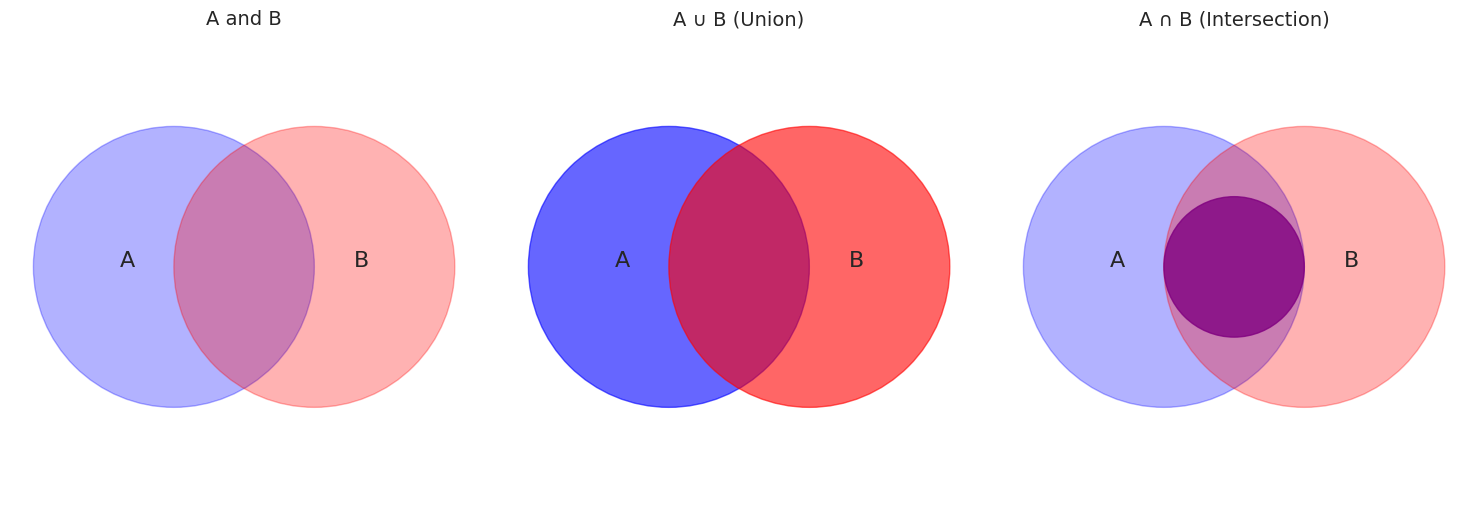

In [3]:
# ベン図の作成（matplotlib-vennがない場合の代替実装）
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 円の描画関数
def draw_venn2(ax, highlight='none', title=''):
    circle1 = plt.Circle((0.35, 0.5), 0.3, alpha=0.3, color='blue', label='A')
    circle2 = plt.Circle((0.65, 0.5), 0.3, alpha=0.3, color='red', label='B')
    
    ax.add_patch(circle1)
    ax.add_patch(circle2)
    
    if highlight == 'union':
        circle1.set_alpha(0.6)
        circle2.set_alpha(0.6)
    elif highlight == 'intersection':
        # 交差部分を強調
        from matplotlib.patches import Wedge
        ax.add_patch(plt.Circle((0.5, 0.5), 0.15, alpha=0.8, color='purple'))
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=14)
    ax.text(0.25, 0.5, 'A', fontsize=16, ha='center')
    ax.text(0.75, 0.5, 'B', fontsize=16, ha='center')
    ax.axis('off')

draw_venn2(axes[0], 'none', 'A and B')
draw_venn2(axes[1], 'union', 'A ∪ B (Union)')
draw_venn2(axes[2], 'intersection', 'A ∩ B (Intersection)')

plt.tight_layout()
plt.show()

## 1.2 確率の公理（コルモゴロフの公理）

### 公理
1. **非負性**: $P(A) \geq 0$ for all $A$
2. **正規化**: $P(\Omega) = 1$
3. **可算加法性**: 互いに排反な事象 $A_1, A_2, ...$ に対して
   $$P\left(\bigcup_{i=1}^{\infty} A_i\right) = \sum_{i=1}^{\infty} P(A_i)$$

### 基本的な性質
- $P(\emptyset) = 0$
- $P(A^c) = 1 - P(A)$
- $A \subseteq B \Rightarrow P(A) \leq P(B)$
- $P(A \cup B) = P(A) + P(B) - P(A \cap B)$ (加法定理)

In [4]:
# 確率の計算例：サイコロ
def calc_probability(event, sample_space):
    """古典的確率の計算"""
    return len(event) / len(sample_space)

P_A = calc_probability(A, omega)
P_B = calc_probability(B, omega)
P_AandB = calc_probability(A & B, omega)
P_AorB = calc_probability(A | B, omega)

print(f"P(A) = {P_A:.4f}")
print(f"P(B) = {P_B:.4f}")
print(f"P(A∩B) = {P_AandB:.4f}")
print(f"P(A∪B) = {P_AorB:.4f}")

# 加法定理の確認
print(f"\n加法定理の確認:")
print(f"P(A) + P(B) - P(A∩B) = {P_A + P_B - P_AandB:.4f}")
print(f"P(A∪B) = {P_AorB:.4f}")

P(A) = 0.5000
P(B) = 0.5000
P(A∩B) = 0.1667
P(A∪B) = 0.8333

加法定理の確認:
P(A) + P(B) - P(A∩B) = 0.8333
P(A∪B) = 0.8333


## 1.3 条件付き確率

### 定義
事象Bが起こったという条件の下での事象Aの確率:

$$P(A|B) = \frac{P(A \cap B)}{P(B)}, \quad P(B) > 0$$

### 乗法定理
$$P(A \cap B) = P(A|B) \cdot P(B) = P(B|A) \cdot P(A)$$

In [5]:
# 条件付き確率のシミュレーション
n_trials = 100000

# サイコロを投げるシミュレーション
rolls = np.random.randint(1, 7, n_trials)

# 事象の定義
event_A = np.isin(rolls, [2, 4, 6])  # 偶数
event_B = np.isin(rolls, [1, 2, 3])  # 3以下

# 条件付き確率 P(A|B)
P_A_given_B_sim = np.sum(event_A & event_B) / np.sum(event_B)

# 理論値
P_A_given_B_theory = P_AandB / P_B

print(f"P(A|B) シミュレーション = {P_A_given_B_sim:.4f}")
print(f"P(A|B) 理論値 = {P_A_given_B_theory:.4f}")
print(f"\n（3以下が出た時に偶数である確率 = 2のみ/3個 = 1/3）")

P(A|B) シミュレーション = 0.3375
P(A|B) 理論値 = 0.3333

（3以下が出た時に偶数である確率 = 2のみ/3個 = 1/3）


## 1.4 ベイズの定理

### 定理
$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

### 全確率の公式
$A_1, A_2, ..., A_n$ が $\Omega$ の分割のとき:
$$P(B) = \sum_{i=1}^{n} P(B|A_i) \cdot P(A_i)$$

### ベイズの定理（一般形）
$$P(A_i|B) = \frac{P(B|A_i) \cdot P(A_i)}{\sum_{j=1}^{n} P(B|A_j) \cdot P(A_j)}$$

In [6]:
# ベイズの定理の例：医療検査
# 病気の有病率: 1%
# 検査の感度（病気の時に陽性）: 99%
# 検査の特異度（健康の時に陰性）: 95%

P_disease = 0.01  # P(D)
P_positive_given_disease = 0.99  # P(+|D)
P_negative_given_healthy = 0.95  # P(-|H)
P_positive_given_healthy = 1 - P_negative_given_healthy  # P(+|H)

# 全確率の公式で P(+) を計算
P_positive = (P_positive_given_disease * P_disease + 
              P_positive_given_healthy * (1 - P_disease))

# ベイズの定理で P(D|+) を計算
P_disease_given_positive = (P_positive_given_disease * P_disease) / P_positive

print("医療検査の例")
print("="*50)
print(f"有病率 P(D) = {P_disease:.2%}")
print(f"感度 P(+|D) = {P_positive_given_disease:.2%}")
print(f"特異度 P(-|H) = {P_negative_given_healthy:.2%}")
print(f"\n陽性になる確率 P(+) = {P_positive:.4f}")
print(f"\n陽性の時に病気である確率 P(D|+) = {P_disease_given_positive:.2%}")

医療検査の例
有病率 P(D) = 1.00%
感度 P(+|D) = 99.00%
特異度 P(-|H) = 95.00%

陽性になる確率 P(+) = 0.0594

陽性の時に病気である確率 P(D|+) = 16.67%


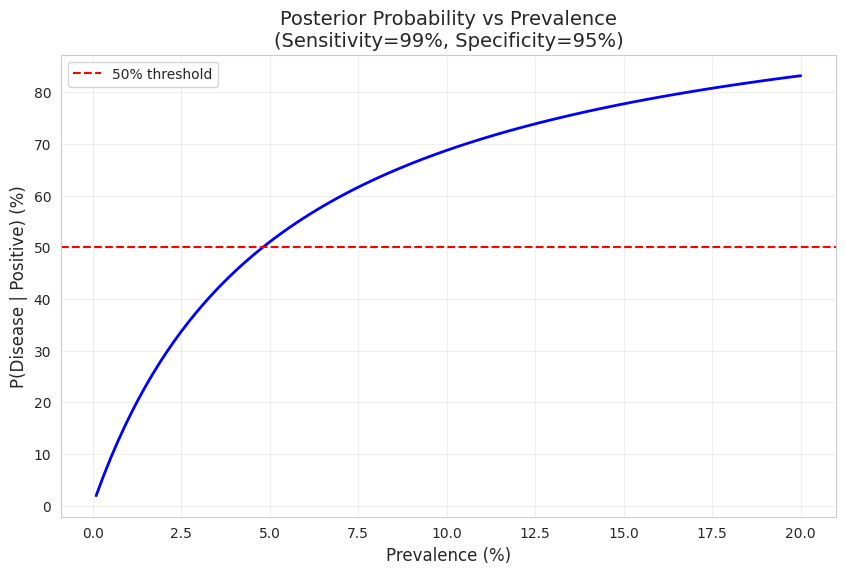

In [7]:
# ベイズの定理の可視化：有病率による事後確率の変化
prevalence = np.linspace(0.001, 0.2, 100)
sensitivity = 0.99
specificity = 0.95

# P(D|+) の計算
P_pos = sensitivity * prevalence + (1 - specificity) * (1 - prevalence)
P_disease_given_pos = (sensitivity * prevalence) / P_pos

plt.figure(figsize=(10, 6))
plt.plot(prevalence * 100, P_disease_given_pos * 100, 'b-', linewidth=2)
plt.xlabel('Prevalence (%)', fontsize=12)
plt.ylabel('P(Disease | Positive) (%)', fontsize=12)
plt.title('Posterior Probability vs Prevalence\n(Sensitivity=99%, Specificity=95%)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axhline(y=50, color='r', linestyle='--', label='50% threshold')
plt.legend()
plt.show()

## 1.5 事象の独立性

### 定義
事象AとBが**独立**であるとは:
$$P(A \cap B) = P(A) \cdot P(B)$$

同値な条件:
- $P(A|B) = P(A)$（Bが起こってもAの確率は変わらない）
- $P(B|A) = P(B)$

### 3つ以上の事象の独立性
$A_1, A_2, ..., A_n$ が**相互独立**であるとは、任意の部分集合 $\{i_1, ..., i_k\}$ に対して:
$$P(A_{i_1} \cap ... \cap A_{i_k}) = P(A_{i_1}) \cdot ... \cdot P(A_{i_k})$$

In [8]:
# 独立性のシミュレーション：2つのサイコロ
n_trials = 100000

dice1 = np.random.randint(1, 7, n_trials)
dice2 = np.random.randint(1, 7, n_trials)

# 事象定義
A = (dice1 >= 4)  # 1つ目が4以上
B = (dice2 % 2 == 0)  # 2つ目が偶数

P_A = np.mean(A)
P_B = np.mean(B)
P_AB = np.mean(A & B)

print("2つのサイコロ（独立な事象）")
print("="*50)
print(f"P(A) = {P_A:.4f} (理論値: 0.5)")
print(f"P(B) = {P_B:.4f} (理論値: 0.5)")
print(f"P(A∩B) = {P_AB:.4f}")
print(f"P(A)×P(B) = {P_A * P_B:.4f}")
print(f"\n独立性の確認: |P(A∩B) - P(A)P(B)| = {abs(P_AB - P_A * P_B):.6f}")

2つのサイコロ（独立な事象）
P(A) = 0.4999 (理論値: 0.5)
P(B) = 0.5008 (理論値: 0.5)
P(A∩B) = 0.2499
P(A)×P(B) = 0.2503

独立性の確認: |P(A∩B) - P(A)P(B)| = 0.000385


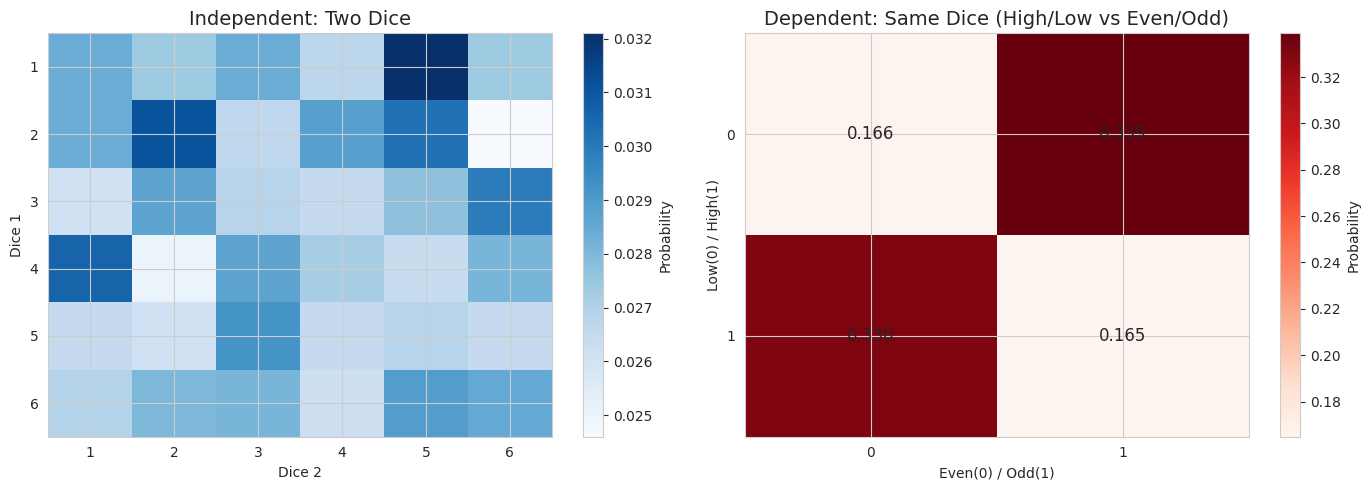

In [9]:
# 独立 vs 従属の比較シミュレーション
n_trials = 10000

# 独立な場合：2つのサイコロ
dice1 = np.random.randint(1, 7, n_trials)
dice2 = np.random.randint(1, 7, n_trials)

# 従属な場合：1つのサイコロで2つの事象
single_dice = np.random.randint(1, 7, n_trials)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 独立：2つのサイコロの同時分布
hist_independent = np.zeros((6, 6))
for i in range(n_trials):
    hist_independent[dice1[i]-1, dice2[i]-1] += 1
hist_independent /= n_trials

im1 = axes[0].imshow(hist_independent, cmap='Blues', aspect='auto')
axes[0].set_title('Independent: Two Dice', fontsize=14)
axes[0].set_xlabel('Dice 2')
axes[0].set_ylabel('Dice 1')
axes[0].set_xticks(range(6))
axes[0].set_yticks(range(6))
axes[0].set_xticklabels(range(1, 7))
axes[0].set_yticklabels(range(1, 7))
plt.colorbar(im1, ax=axes[0], label='Probability')

# 従属：サイコロの出目と偶奇
even_odd = single_dice % 2  # 0: even, 1: odd
high_low = (single_dice > 3).astype(int)  # 0: low, 1: high

hist_dependent = np.zeros((2, 2))
for i in range(n_trials):
    hist_dependent[high_low[i], even_odd[i]] += 1
hist_dependent /= n_trials

im2 = axes[1].imshow(hist_dependent, cmap='Reds', aspect='auto')
axes[1].set_title('Dependent: Same Dice (High/Low vs Even/Odd)', fontsize=14)
axes[1].set_xlabel('Even(0) / Odd(1)')
axes[1].set_ylabel('Low(0) / High(1)')
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, f'{hist_dependent[i,j]:.3f}', 
                     ha='center', va='center', fontsize=12)
plt.colorbar(im2, ax=axes[1], label='Probability')

plt.tight_layout()
plt.show()

## 1.6 練習問題

### 問題1
52枚のトランプから1枚引くとき、以下の確率を求めよ。
1. ハートまたは絵札（J, Q, K）である確率
2. ハートである条件の下で絵札である確率

### 問題2
3つの箱A, B, Cがある。
- 箱A: 白球3個、黒球2個
- 箱B: 白球2個、黒球3個
- 箱C: 白球1個、黒球4個

等確率で1つの箱を選び、その箱から1球取り出したところ白球だった。この球が箱Aから取り出された確率を求めよ。

### 問題3
次の事象A, B, Cが相互独立であるか確認せよ。
- 2つのサイコロを投げる
- A: 1つ目が偶数
- B: 2つ目が偶数
- C: 合計が偶数

In [10]:
# 練習問題1の解答例
# トランプの標本空間
suits = ['Heart', 'Diamond', 'Club', 'Spade']
ranks = list(range(1, 14))  # 1-13 (A, 2-10, J, Q, K)

# 全カード
deck = [(suit, rank) for suit in suits for rank in ranks]
n_cards = len(deck)

# 事象
hearts = {card for card in deck if card[0] == 'Heart'}
face_cards = {card for card in deck if card[1] >= 11}  # J, Q, K

# 1. ハートまたは絵札
hearts_or_face = hearts | face_cards
P_hearts_or_face = len(hearts_or_face) / n_cards

# 2. ハートの条件下で絵札
hearts_and_face = hearts & face_cards
P_face_given_heart = len(hearts_and_face) / len(hearts)

print("問題1の解答")
print("="*50)
print(f"1. P(Heart ∪ Face) = {len(hearts_or_face)}/{n_cards} = {P_hearts_or_face:.4f}")
print(f"2. P(Face | Heart) = {len(hearts_and_face)}/{len(hearts)} = {P_face_given_heart:.4f}")

問題1の解答
1. P(Heart ∪ Face) = 22/52 = 0.4231
2. P(Face | Heart) = 3/13 = 0.2308


In [11]:
# 練習問題2の解答例（ベイズの定理）
# 事前確率
P_A = P_B = P_C = 1/3

# 尤度（各箱から白球を引く確率）
P_W_given_A = 3/5
P_W_given_B = 2/5
P_W_given_C = 1/5

# 全確率
P_W = P_W_given_A * P_A + P_W_given_B * P_B + P_W_given_C * P_C

# ベイズの定理
P_A_given_W = (P_W_given_A * P_A) / P_W

print("問題2の解答")
print("="*50)
print(f"P(White) = {P_W:.4f}")
print(f"P(A | White) = {P_A_given_W:.4f} = {P_A_given_W}")

問題2の解答
P(White) = 0.4000
P(A | White) = 0.5000 = 0.5


In [12]:
# 練習問題3の解答例
print("問題3の解答")
print("="*50)

# 標本空間: 36通り
# A: 1つ目が偶数 → {2,4,6} × {1,...,6} = 18通り → P(A) = 1/2
# B: 2つ目が偶数 → {1,...,6} × {2,4,6} = 18通り → P(B) = 1/2
# C: 合計が偶数 → 18通り → P(C) = 1/2

# シミュレーションで確認
n_trials = 100000
d1 = np.random.randint(1, 7, n_trials)
d2 = np.random.randint(1, 7, n_trials)

A = (d1 % 2 == 0)
B = (d2 % 2 == 0)
C = ((d1 + d2) % 2 == 0)

# 2事象の積
P_AB = np.mean(A & B)
P_AC = np.mean(A & C)
P_BC = np.mean(B & C)

# 3事象の積
P_ABC = np.mean(A & B & C)

P_A_val = np.mean(A)
P_B_val = np.mean(B)
P_C_val = np.mean(C)

print(f"P(A) = {P_A_val:.4f}, P(B) = {P_B_val:.4f}, P(C) = {P_C_val:.4f}")
print(f"\nペアワイズ独立性の確認:")
print(f"P(A∩B) = {P_AB:.4f}, P(A)P(B) = {P_A_val*P_B_val:.4f}")
print(f"P(A∩C) = {P_AC:.4f}, P(A)P(C) = {P_A_val*P_C_val:.4f}")
print(f"P(B∩C) = {P_BC:.4f}, P(B)P(C) = {P_B_val*P_C_val:.4f}")
print(f"\n相互独立性の確認:")
print(f"P(A∩B∩C) = {P_ABC:.4f}, P(A)P(B)P(C) = {P_A_val*P_B_val*P_C_val:.4f}")
print(f"\n結論: A, B, Cはペアワイズ独立だが、相互独立ではない")
print(f"（Cが起こる ⇔ AとBが同時に起こるか同時に起こらない）")

問題3の解答
P(A) = 0.4973, P(B) = 0.5001, P(C) = 0.5006

ペアワイズ独立性の確認:
P(A∩B) = 0.2490, P(A)P(B) = 0.2487
P(A∩C) = 0.2490, P(A)P(C) = 0.2489
P(B∩C) = 0.2490, P(B)P(C) = 0.2503

相互独立性の確認:
P(A∩B∩C) = 0.2490, P(A)P(B)P(C) = 0.1245

結論: A, B, Cはペアワイズ独立だが、相互独立ではない
（Cが起こる ⇔ AとBが同時に起こるか同時に起こらない）
